In [68]:
import sys
from PIL import Image
import numpy as np
import skimage.io as io
import skimage.color as color
from skimage import transform
import matplotlib.pyplot as plt
import cv2
import random
from numpy.lib import stride_tricks

In [69]:
def RGBtoHSV(img):
    """
    print("---- BEFORE NORMALIZING ----")
    print(img)
    img[:][:] = img[:][:] / 255.0
    """
    
    """
    print("---- After NORMALIZING ----")
    print(img)
    """
        
    for i in range(len(img)):
        for j in range( len(img[i]) ):
            
            (r,g,b) = img[i][j]
            max_col = max(r,g,b)
            min_col = min(r,g,b)
            c = max_col - min_col
            
            if max_col == min_col:
                hue = 0
            elif max_col == r:
                hue = 60 * (((g-b)/c) % 6) 
            elif max_col == g:
                hue = 60 * (((b-r)/c) + 2.0)
            elif max_col == b:
                hue = 60 * (((r-g)/c) + 4.0)
            
            if max_col == 0:
                sat = 0
            else:
                sat = c/max_col
                
            val = max_col
            hue = hue/360.0
            
            img[i][j] = (hue,sat,val)
            
    # Creating array back into image
    """
    print("---- After Calculations ----")
    print(img)

    img_save = img * 255
    img_save = img_save.astype(np.uint8)
    io.imsave("puppy2.png",img_save)
    print("----After Compression---")
    print(img_save)
    """
    
    return img

def HSVtoRGB(img):
    for i in range(len(img)):
        for j in range( len(img[i]) ):
            (hue,sat,val) = img[i][j]
            c = val * sat
            h_p = hue/60
            x = c * (1 - (abs( (h_p % 2) - 1)))
            
            if ((h_p >= 0) and (h_p < 1)):
                (r,g,b) = (c,x,0)
            elif ((h_p >= 1) and (h_p < 2)):
                (r,g,b) = (x,c,0)
            elif ((h_p >= 2) and (h_p < 3)):
                (r,g,b) = (0,c,x)
            elif ((h_p >= 3) and (h_p < 4)):
                (r,g,b) = (0,x,c)
            elif ((h_p >= 4) and (h_p < 5)):
                (r,g,b) = (x,0,c)
            elif ((h_p >= 5) and (h_p < 6)):
                (r,g,b) = (c,0,x)
            
            m = val - c
            (r,g,b) = ( r+m, g+m, b+m )
            img[i][j] = (r,g,b)
            
    return img

In [70]:
# Expect numpy_array and integer values to calculate random crop
def random_crop(img,size):
    s = size
    (height, width, channel) = img.shape
    possible = False
    while not(possible):
        center_h = random.randint(0,height)
        center_w = random.randint(0,width)
        square_conditions = (((center_h + s) < height) and ((center_w + s) < width)) and (((center_h - s) > 0) and ((center_w - s) > 0))
        if square_conditions: 
            possible = True

    img_crop = img[(center_h - s):(center_h + s),(center_w - s):(center_w + s)]

    plt.imshow(img_crop)
    plt.show()
    
def extract_patch(img, num_patches):
    # non-overlapping patches of size 8
    size = num_patches
    H, W, C = img.shape
    shape = [H // size, W // size] + [size, size]

    # (row, col, patch_row, patch_col)
    strides = [size * s for s in img.strides[:1]] + list(img.strides)
    # extract patches
    patches = stride_tricks.as_strided(img, shape=shape, strides=strides)
    
    return patches
    
def color_jitter(img, hue, saturation, value):
    img_hsv = RGBtoHSV(img)
    
    ran_hue = random.randint(0,hue)
    ran_sat = random.uniform(0,saturation)
    ran_val = random.uniform(0,value)
    
    img_hsv[:,:,0] += ran_hue
    img_hsv[:,:,1] += ran_sat
    img_hsv[:,:,2] += ran_val

    plt.imshow(HSVtoRGB(img_hsv))
    plt.show()
    
def resize_img(img, factor):
    img_rescaled = transform.rescale(img, factor, anti_aliasing=False)
    plt.imshow(img_rescaled)
    plt.show()

In [71]:
"""
if __name__ == '__main__':
    if len(sys.argv) != 3:
        print("[ERROR] Incorrect arguments. Format: FILENAME INTEGER")
        print("[ERROR] Note: Integer must be within image size")
        quit()
    
    # --- DEBUG ----
    print(f"[DEBUG] Arguments count: { len(sys.argv) }")
    for i, arg in enumerate( sys.argv ):
        print(f"[DEBUG] Argument {i}: {arg}")
    
    # Setting command line argument values
    filename = sys.argv[1]
    s = sys.argv[2]
     
"""

'\nif __name__ == \'__main__\':\n    if len(sys.argv) != 3:\n        print("[ERROR] Incorrect arguments. Format: FILENAME INTEGER")\n        print("[ERROR] Note: Integer must be within image size")\n        quit()\n    \n    # --- DEBUG ----\n    print(f"[DEBUG] Arguments count: { len(sys.argv) }")\n    for i, arg in enumerate( sys.argv ):\n        print(f"[DEBUG] Argument {i}: {arg}")\n    \n    # Setting command line argument values\n    filename = sys.argv[1]\n    s = sys.argv[2]\n     \n'

In [72]:
img = io.imread("puppy.png")

# Convert to RGB from RGBA (if applicable)
if img.ndim == 3 and img.shape[2] == 4:
    img = color.rgba2rgb(img)
    
print('Type:', type(img))
print('dtype:', img.dtype)
print('shape:', img.shape)

"""
size_cond = (s.isdigit() and ((s > 0) and ((s < height) and (s < width))) )
if not(size_condition):
    print(f"[ERROR] inputed cropping size ({s}) by user exceed image size or isn't a digit")
    quit()
"""
s = 200 # GET RID OF IN PYTHON

Type: <class 'numpy.ndarray'>
dtype: float64
shape: (1073, 860, 3)


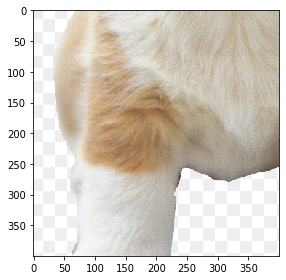

In [73]:
random_crop(img,s)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


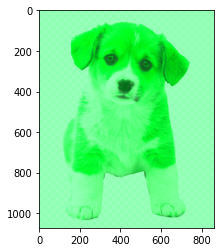

In [74]:
img = io.imread("puppy.png")

# Convert to RGB from RGBA (if applicable)
if img.ndim == 3 and img.shape[2] == 4:
    img = color.rgba2rgb(img)

color_jitter(img, 200, 0.7, 0.4)

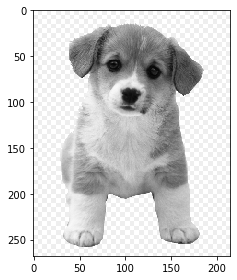

In [76]:
img = io.imread("puppy.png")

# Convert to RGB from RGBA (if applicable)
if img.ndim == 3 and img.shape[2] == 4:
    img = color.rgba2rgb(img)

resize_img(img,0.25)